# BÀI THỰC HÀNH 06. REGION BASED SEGMENTATION
Trong bài thực hành này, chúng ta sẽ áp dụng các phương pháp phân đoạn dựa trên vùng (Region-based Segmentation), bao gồm: K-means, Region Growing, Watershed và Split-Merge.


## 0. Các hàm dùng chung cho toàn bài
Khởi tạo môi trường, cài đặt các hàm hỗ trợ đọc ảnh, xử lý và hiển thị trực quan.


In [1]:
import os
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from matplotlib import patches

def read_gray_image(path, to_float=False):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Không thể đọc ảnh: {path}")
        return None
    if to_float:
        return img.astype(np.float32) / 255.0
    return img

def show_gray(img, title='Gray image', figsize=(5, 5), cmap='gray'):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def show_images(images, titles=None, cols=3, figsize=(14, 8), cmap='gray'):
    n = len(images)
    rows = math.ceil(n / cols)
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        if titles is not None and i < len(titles):
            plt.title(titles[i])
    plt.tight_layout()
    plt.show()

def colorize_label_map(label_map):
    label_map = label_map.astype(np.int32)
    max_label = label_map.max()
    if max_label <= 0:
        return np.zeros((*label_map.shape, 3), dtype=np.uint8)
    rng = np.random.default_rng(0)
    colors = rng.integers(0, 255, size=(max_label + 1, 3), dtype=np.uint8)
    colors[0] = np.array([0, 0, 0], dtype=np.uint8)
    return colors[label_map]

def overlay_mask_on_gray(gray, mask, color=(255, 0, 0), alpha=0.35):
    if gray.dtype != np.uint8:
        gray_u8 = np.clip(gray * 255 if gray.max() <= 1.0 else gray, 0, 255).astype(np.uint8)
    else:
        gray_u8 = gray.copy()
    rgb = cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2RGB).astype(np.float32)
    mask_bool = mask > 0
    overlay = rgb.copy()
    overlay[mask_bool] = (1 - alpha) * overlay[mask_bool] + alpha * np.array(color, dtype=np.float32)
    return np.clip(overlay, 0, 255).astype(np.uint8)

def draw_watershed_boundaries(gray, markers, boundary_value=-1):
    if gray.dtype != np.uint8:
        gray_u8 = np.clip(gray * 255 if gray.max() <= 1.0 else gray, 0, 255).astype(np.uint8)
    else:
        gray_u8 = gray.copy()
    rgb = cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2RGB)
    rgb[markers == boundary_value] = [255, 0, 0]
    return rgb

def draw_quadtree_boxes(gray, rectangles, title='Quadtree split result'):
    plt.figure(figsize=(6, 6))
    plt.imshow(gray, cmap='gray')
    ax = plt.gca()
    for (x, y, w, h) in rectangles:
        rect = patches.Rectangle((y, x), w, h, linewidth=1.2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


## 1. Phương pháp 1: K-means segmentation
K-means là phương pháp gom cụm. Chúng ta thử nghiệm bằng cách gộp nhóm giá trị pixel theo:
- Độ sáng thuần túy (Intensity).
- Tính thêm khoảng cách toạ độ không gian (Intensity + X, Y).


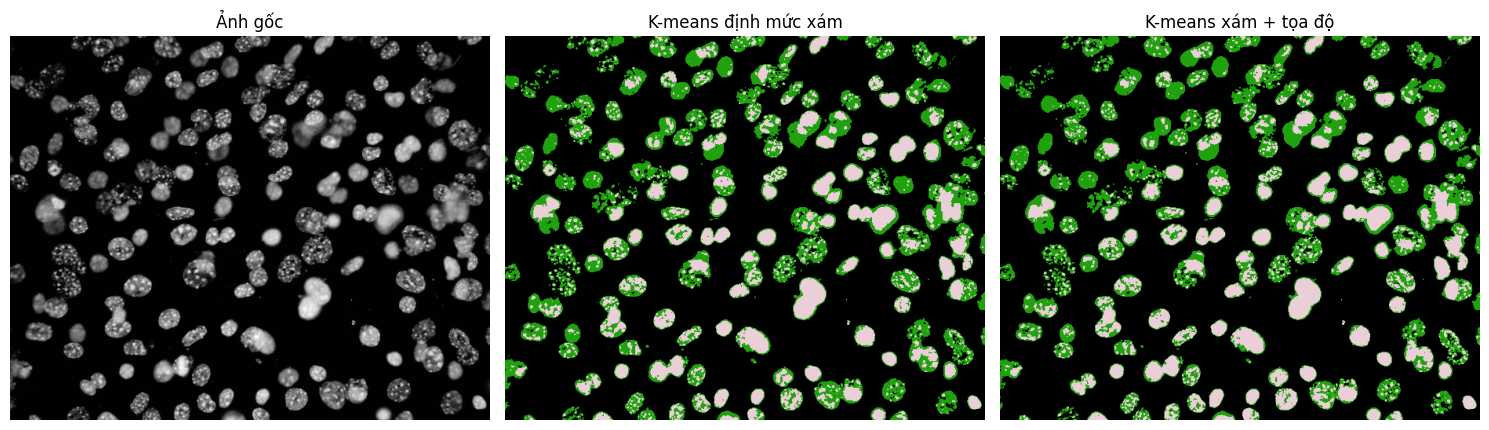

In [2]:
def kmeans_gray_intensity(gray, k=3, max_iter=30, tol=1e-4, seed=0):
    X = gray.astype(np.float32).reshape(-1, 1)
    rng = np.random.default_rng(seed)
    
    # Init centers randomly
    init_idx = rng.choice(X.shape[0], size=k, replace=False)
    centers = X[init_idx].copy()
    
    for _ in range(max_iter):
        dists = np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2)
        labels = np.argmin(dists, axis=1)
        
        new_centers = centers.copy()
        for c in range(k):
            pts = X[labels == c]
            if len(pts) > 0:
                new_centers[c] = pts.mean(axis=0)
                
        shift = np.linalg.norm(new_centers - centers)
        centers = new_centers
        if shift < tol:
            break
            
    label_map = labels.reshape(gray.shape)
    return label_map, centers.reshape(-1)

def kmeans_gray_intensity_xy(gray, k=3, spatial_weight=0.25, max_iter=30, tol=1e-4, seed=0):
    h, w = gray.shape
    yy, xx = np.mgrid[0:h, 0:w]
    I = gray.astype(np.float32) / 255.0
    
    X = np.stack([
        I,
        spatial_weight * (yy.astype(np.float32) / max(h - 1, 1)),
        spatial_weight * (xx.astype(np.float32) / max(w - 1, 1))
    ], axis=-1).reshape(-1, 3)
    
    rng = np.random.default_rng(seed)
    init_idx = rng.choice(X.shape[0], size=k, replace=False)
    centers = X[init_idx].copy()
    
    for _ in range(max_iter):
        dists = np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2)
        labels = np.argmin(dists, axis=1)
        
        new_centers = centers.copy()
        for c in range(k):
            pts = X[labels == c]
            if len(pts) > 0:
                new_centers[c] = pts.mean(axis=0)
        
        shift = np.linalg.norm(new_centers - centers)
        centers = new_centers
        if shift < tol:
            break
            
    label_map = labels.reshape(gray.shape)
    return label_map, centers

# Thực thi và hiển thị kết quả
gray_km = read_gray_image('../Resources/cell1.jpg')
if gray_km is not None:
    label_1, _ = kmeans_gray_intensity(gray_km, k=3)
    label_2, _ = kmeans_gray_intensity_xy(gray_km, k=3, spatial_weight=0.35)
    show_images(
        [gray_km, colorize_label_map(label_1), colorize_label_map(label_2)],
        ['Ảnh gốc', 'K-means định mức xám', 'K-means xám + tọa độ'],
        cols=3, figsize=(15, 5))


## 2. Phương pháp 2: Region Growing
Phương pháp bắt đầu bằng 1 hạt giống (seed) và "mọc" ra xung quanh nếu các pixel đạt điều kiện tương đồng.
- `region_growing_seed_ref`: So sánh với giá trị pixel tại hạt giống ban đầu.
- Ta sẽ minh họa với việc chọn Seed tốt. 


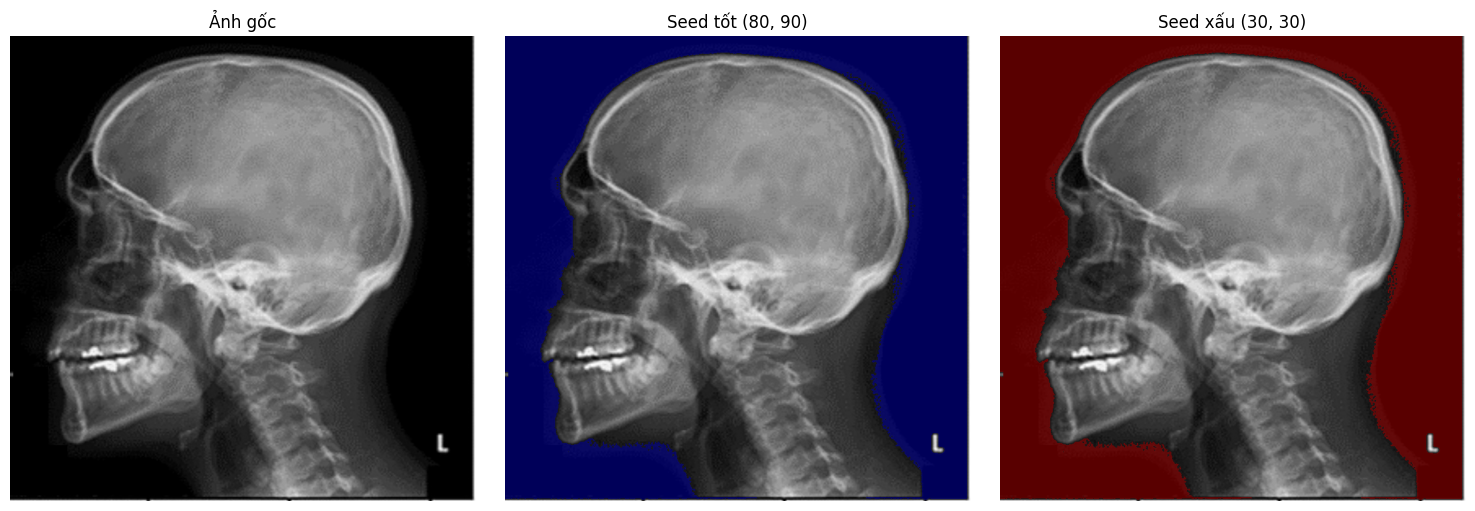

In [3]:
def region_growing_seed_ref(gray, seed, threshold=8, connectivity=4):
    h, w = gray.shape
    visited = np.zeros((h, w), dtype=bool)
    region = np.zeros((h, w), dtype=np.uint8)
    
    seed_x, seed_y = seed
    seed_val = int(gray[seed_x, seed_y])
    q = deque([(seed_x, seed_y)])
    
    if connectivity == 8:
        neighbors = [(-1, -1), (-1, 0), (-1, 1),
                     (0, -1), (0, 1),
                     (1, -1), (1, 0), (1, 1)]
    else:
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        
    while q:
        x, y = q.popleft()
        if visited[x, y]:
            continue
        visited[x, y] = True
        
        if abs(int(gray[x, y]) - seed_val) <= threshold:
            region[x, y] = 255
            for dx, dy in neighbors:
                nx, ny = x + dx, y + dy
                if 0 <= nx < h and 0 <= ny < w and not visited[nx, ny]:
                    q.append((nx, ny))
    return region

gray_rg = read_gray_image('../Resources/bone1.jpg')
if gray_rg is not None:
    seed_good = (80, 90) # Adjust based on bone1.jpg structure (a relatively bright spot)
    seed_bad = (30, 30) # A darker background spot
    
    # Using threshold 20 to allow a bit more variation
    mask_good = region_growing_seed_ref(gray_rg, seed_good, threshold=20)
    mask_bad = region_growing_seed_ref(gray_rg, seed_bad, threshold=20)
    
    over_good = overlay_mask_on_gray(gray_rg, mask_good)
    over_bad = overlay_mask_on_gray(gray_rg, mask_bad, color=(0, 0, 255))
    
    show_images([gray_rg, over_good, over_bad],
                ['Ảnh gốc', f'Seed tốt {seed_good}', f'Seed xấu {seed_bad}'],
                cols=3, figsize=(15, 5))


## 3. Phương pháp 3: Watershed và Distance Transform
Đại diện cho việc chia tách các đối tượng nằm sát nhau hoặc dính chùm vào nhau. Thường kết hợp với Morphology và Distance Transform.


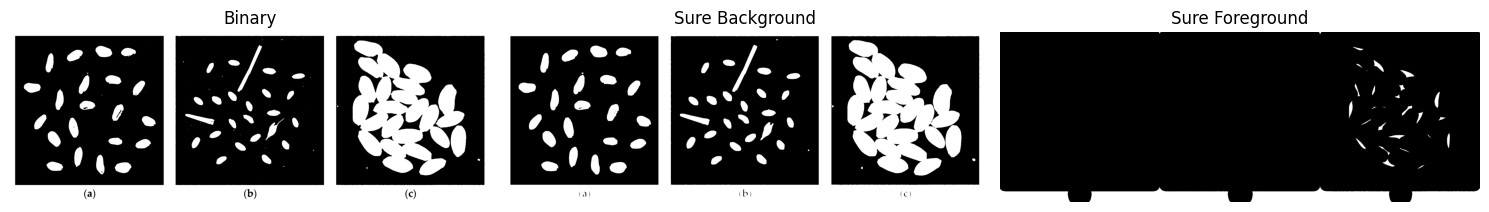

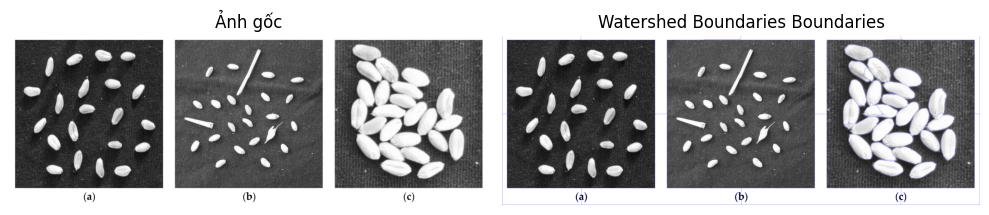

In [4]:
def watershed_from_binary(gray, blur_ksize=3, dist_ratio=0.45, open_iter=2, dilate_iter=2):
    if blur_ksize > 1:
        gray_blur = cv2.GaussianBlur(gray, (blur_ksize, blur_ksize), 0)
    else:
        gray_blur = gray.copy()
        
    # Threshold Otsu
    _, binary = cv2.threshold(gray_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Opening loại nhiễu
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=open_iter)
    
    # Dilation lấy sure background
    sure_bg = cv2.dilate(opening, kernel, iterations=dilate_iter)
    
    # Distance Transform
    dist_map = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    
    # Sure Foreground
    _, sure_fg = cv2.threshold(dist_map, dist_ratio * dist_map.max(), 255, 0)
    sure_fg = sure_fg.astype(np.uint8)
    
    # Điểm chưa xác định
    unknown = cv2.subtract(sure_bg, sure_fg)
    
    # Marker Labeling
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    
    color_input = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    markers_ws = cv2.watershed(color_input, markers.copy())
    
    return {
        'gray_blur': gray_blur,
        'binary': binary,
        'opening': opening,
        'sure_bg': sure_bg,
        'dist_map': dist_map,
        'sure_fg': sure_fg,
        'unknown': unknown,
        'markers_before': markers,
        'markers_after': markers_ws
    }

gray_ws = read_gray_image('../Resources/seeds_count1.png')
if gray_ws is not None:
    out = watershed_from_binary(gray_ws, dist_ratio=0.35)
    
    # Cần đảo ngược mask gốc nếu hạt tối trên nền sáng (tùy ảnh). Với hạt, thường hạt đen:
    # Trường hợp ảnh seeds_count1: background trắng (255), hạt đen (0).
    # Otsu mặc định lấy vùng sáng làm foreground. Sửa lỗi trên nếu cần.
    # Kiểm tra tỷ lệ background để đảo ngược nếu cần:
    if np.mean(gray_ws) > 127: # Phần lớn mảng sáng (nền giấy/v.v), hạt đen.
        gray_ws_inv = 255 - gray_ws
        out = watershed_from_binary(gray_ws_inv, dist_ratio=0.3)
        
    show_images([out['binary'], out['sure_bg'], out['sure_fg']],
                ['Binary', 'Sure Background', 'Sure Foreground'], cols=3, figsize=(15, 5))
                
    overlay_ws = draw_watershed_boundaries(gray_ws, out['markers_after'])
    show_images([gray_ws, overlay_ws], ['Ảnh gốc', 'Watershed Boundaries Boundaries'], cols=2, figsize=(10, 5))


## 4. Phương pháp 4: Split-Merge segmentation
Đánh giá độ phân tán (Variance) của khu vực, nếu phương sai quá cao tức là cấu trúc không đồng nhất -> Tách thành 4 hình chữ nhật con (Split). Tiếp tục hợp nhất khu vực kề cạnh nếu mean gần nhau.


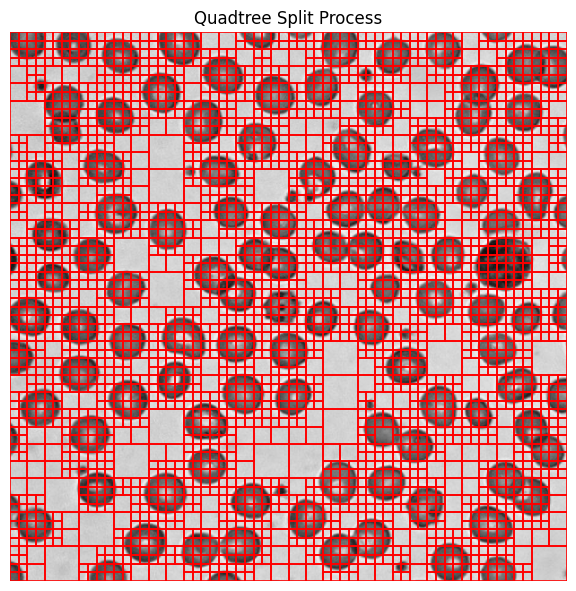

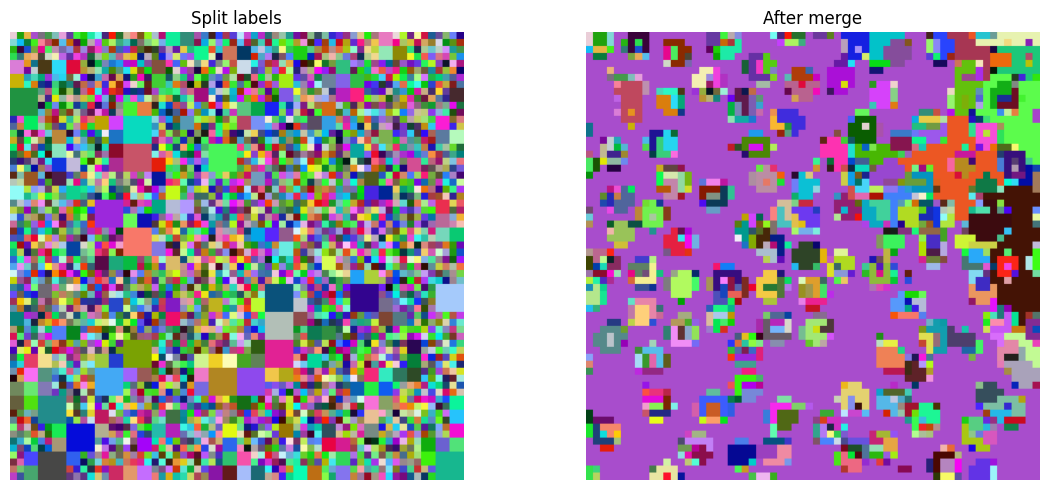

In [5]:
def quadtree_split(gray, min_size=16, var_thresh=80.0):
    h, w = gray.shape
    rectangles = []
    
    def recurse(x, y, hh, ww):
        region = gray[x:x+hh, y:y+ww]
        variance = float(np.var(region))
        
        if hh <= min_size or ww <= min_size or variance < var_thresh:
            rectangles.append((x, y, ww, hh))
            return
            
        h2 = hh // 2
        w2 = ww // 2
        
        if h2 == 0 or w2 == 0:
            rectangles.append((x, y, ww, hh))
            return
            
        recurse(x, y, h2, w2)
        recurse(x, y + w2, h2, ww - w2)
        recurse(x + h2, y, hh - h2, w2)
        recurse(x + h2, y + w2, hh - h2, ww - w2)
        
    recurse(0, 0, h, w)
    return rectangles

def quadtree_rectangles_to_label_map(shape, rectangles):
    h, w = shape
    label_map = np.zeros((h, w), dtype=np.int32)
    for idx, (x, y, ww, hh) in enumerate(rectangles, start=1):
        label_map[x:x+hh, y:y+ww] = idx
    return label_map

def merge_adjacent_rectangles(gray, rectangles, mean_thresh=8.0):
    means = [float(np.mean(gray[x:x+hh, y:y+ww])) for (x, y, ww, hh) in rectangles]
    
    def are_adjacent(r1, r2):
        x1, y1, w1, h1 = r1
        x2, y2, w2, h2 = r2
        horiz_touch = (x1 < x2 + h2 and x2 < x1 + h1) and (y1 + w1 == y2 or y2 + w2 == y1)
        vert_touch = (y1 < y2 + w2 and y2 < y1 + w1) and (x1 + h1 == x2 or x2 + h2 == x1)
        return horiz_touch or vert_touch
        
    n = len(rectangles)
    visited = [False] * n
    groups = []
    
    for i in range(n):
        if visited[i]:
            continue
        q = deque([i])
        visited[i] = True
        group = [i]
        
        while q:
            u = q.popleft()
            for v in range(n):
                if not visited[v] and are_adjacent(rectangles[u], rectangles[v]):
                    if abs(means[u] - means[v]) <= mean_thresh:
                        visited[v] = True
                        q.append(v)
                        group.append(v)
        groups.append(group)
    return groups

def groups_to_label_map(shape, rectangles, groups):
    h, w = shape
    label_map = np.zeros((h, w), dtype=np.int32)
    for label, group in enumerate(groups, start=1):
        for idx in group:
            x, y, ww, hh = rectangles[idx]
            label_map[x:x+hh, y:y+ww] = label
    return label_map

gray_sm = read_gray_image('../Resources/RBC2.jpg')
if gray_sm is not None:
    # Using RBC2 to demonstrate Split Merge (since it has large background uniformity)
    rects = quadtree_split(gray_sm, min_size=16, var_thresh=150.0)
    label_split = quadtree_rectangles_to_label_map(gray_sm.shape, rects)
    
    groups = merge_adjacent_rectangles(gray_sm, rects, mean_thresh=15.0)
    label_merge = groups_to_label_map(gray_sm.shape, rects, groups)
    
    draw_quadtree_boxes(gray_sm, rects, title='Quadtree Split Process')
    show_images([colorize_label_map(label_split), colorize_label_map(label_merge)],
                ['Split labels', 'After merge'], cols=2, figsize=(12, 5), cmap='gray')
